In [93]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [94]:
# Data Loading
df_train = pd.read_csv("train.csv")

In [10]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [13]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [14]:
# Columns with Null values
df_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [95]:
# Drop Cabin Column
df_train = df_train.drop(columns= "Cabin")

In [96]:
# Fill Age nulls with median
df_train["Age"] = df_train["Age"].fillna(df_train["Age"].median())

In [97]:
# Fill Embarked nulls values with mode
df_train["Embarked"] = df_train["Embarked"].fillna(df_train["Embarked"].mode()[0])

In [ ]:
# Recheck null values
df_train.isnull().sum()

df_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


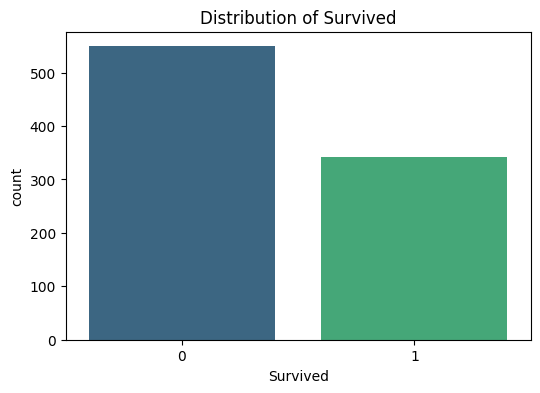

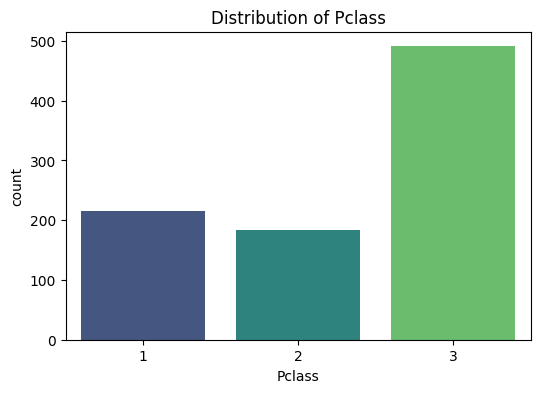

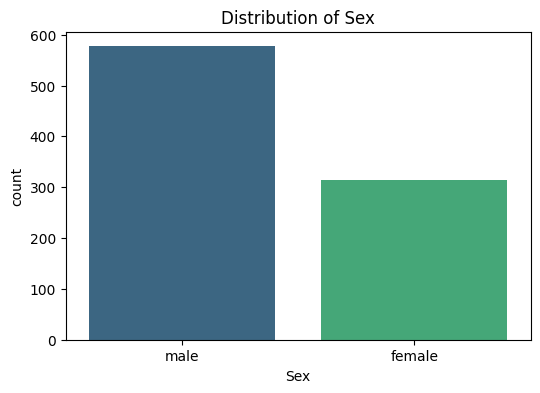

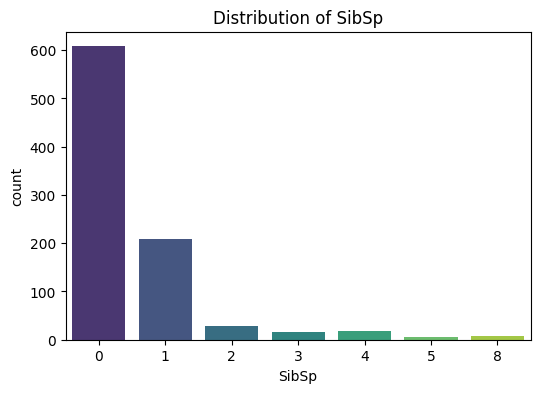

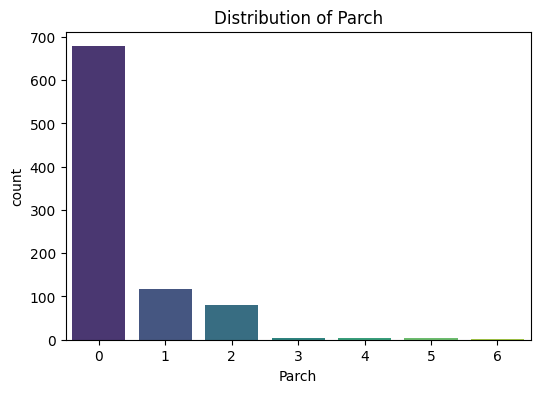

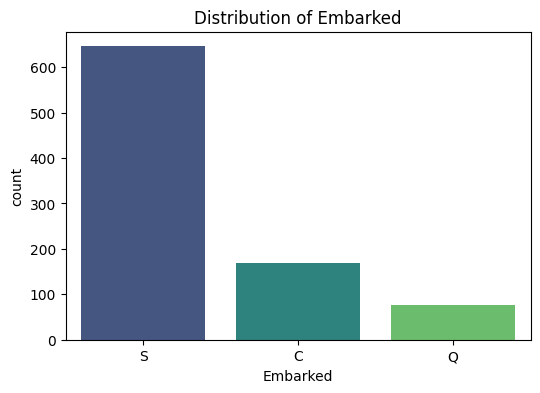

In [25]:
# Categorical columns
cat_cols = ["Survived", "Pclass", "Sex", "SibSp", "Parch", "Embarked"]
for col in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=df_train[col], palette="viridis")
    plt.title(f"Distribution of {col}")
    plt.show()

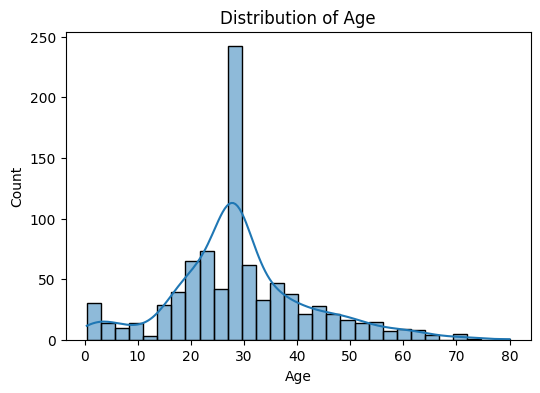

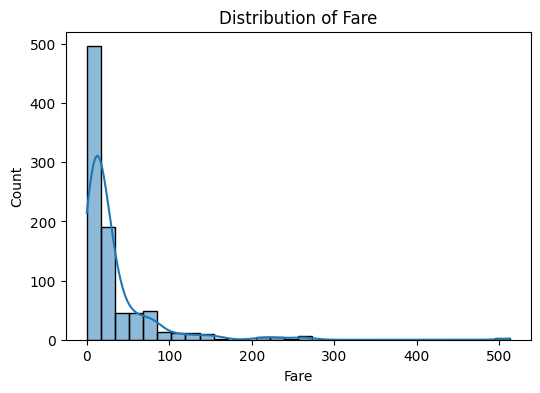

In [26]:
# Continuous columns
cont_cols = ["Age", "Fare"]
for col in cont_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df_train[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

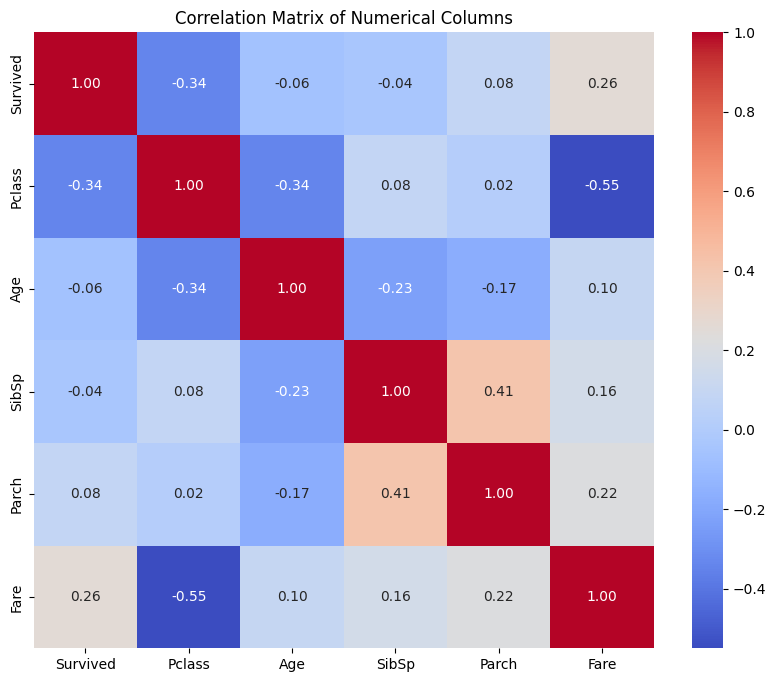

In [ ]:
# Correlation Matrix of Numerical Columns 
plt.figure(figsize= (10,8))
sns.heatmap(df_train.drop(columns= ["PassengerId", "Name", "Ticket"]).corr(numeric_only= True), annot= True, cmap= "coolwarm", fmt= ".2f") # Drop Identifier Columns
plt.title("Correlation Matrix of Numerical Columns")
plt.show()

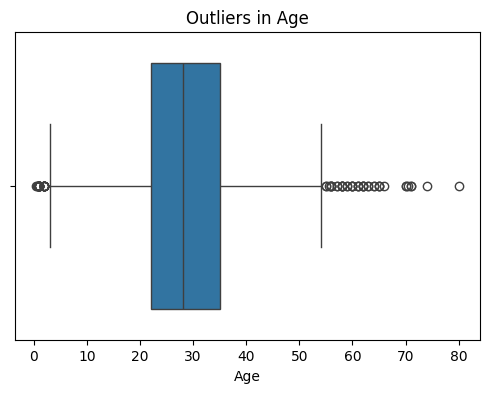

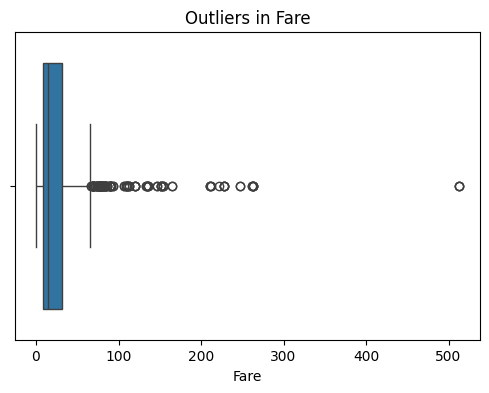

In [ ]:
# Outliers
for col in cont_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df_train[col])
    plt.title(f'Outliers in {col}')
    plt.show()

In [48]:
df_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,111369,30.0000,C148,C


In [98]:
# Label Encode
df_train["Sex"] = df_train["Sex"].str.strip()
df_train["Sex"] = df_train["Sex"].map({"male": 0, "female": 1})
df_train["Sex"]

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    1
889    0
890    0
Name: Sex, Length: 891, dtype: int64

In [99]:
# Drop Identifier Columns
df_train = df_train.drop(columns= ["PassengerId", "Name", "Ticket"])

In [58]:
df_train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,S
1,1,1,1,38.0,1,0,71.2833,C
2,1,3,1,26.0,0,0,7.9250,S
3,1,1,1,35.0,1,0,53.1000,S
4,0,3,0,35.0,0,0,8.0500,S


In [100]:
# Hot Label Encoding 
df_train = pd.get_dummies(df_train, columns=["Embarked"])
df_train = df_train.astype({col: int for col in df_train.select_dtypes(include="bool").columns})

df_train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,0,1
1,1,1,1,38.0,1,0,71.2833,1,0,0
2,1,3,1,26.0,0,0,7.9250,0,0,1
3,1,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,0,35.0,0,0,8.0500,0,0,1


In [101]:
# Feature Selection
from scipy.stats import f_oneway

numerical_cols = df_train.select_dtypes(include=np.number).columns.tolist() 


if 'Survived' in numerical_cols: # Remove Target Variable/Column
    numerical_cols.remove('Survived')

print("Correlation with Survived:")
print(df_train[numerical_cols + ['Survived']].corr()['Survived'].sort_values(ascending=False).drop('Survived'))


Correlation with Survived:
Sex           0.543351
Fare          0.257307
Embarked_C    0.168240
Parch         0.081629
Embarked_Q    0.003650
SibSp        -0.035322
Age          -0.064910
Embarked_S   -0.149683
Pclass       -0.338481
Name: Survived, dtype: float64


In [102]:
# Drop Least Correlated Columns
df_train = df_train.drop(columns= ["Parch", "Embarked_Q"])
df_train.head()

,Survived,Pclass,Sex,Age,SibSp,Fare,Embarked_C,Embarked_S
0,0,3,0,22.0,1,7.2500,0,1
1,1,1,1,38.0,1,71.2833,1,0
2,1,3,1,26.0,0,7.9250,0,1
3,1,1,1,35.0,1,53.1000,0,1
4,0,3,0,35.0,0,8.0500,0,1


In [103]:
# Feature Scaling --> StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Only scale continuous columns
df_train[["Age", "Fare"]] = scaler.fit_transform(df_train[["Age", "Fare"]])

In [104]:
df_train.head()

,Survived,Pclass,Sex,Age,SibSp,Fare,Embarked_C,Embarked_S
0,0,3,0,-0.565736,1,-0.502445,0,1
1,1,1,1,0.663861,1,0.786845,1,0
2,1,3,1,-0.258337,0,-0.488854,0,1
3,1,1,1,0.433312,1,0.420730,0,1
4,0,3,0,0.433312,0,-0.486337,0,1


In [105]:
# Split X and y
X = df_train.drop(columns= "Survived")
y = df_train["Survived"]

In [106]:
# Split train and test data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [107]:
# Logistic Regression and Accuracy metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results:
Accuracy: 0.7988826815642458
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       105
           1       0.76      0.74      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [108]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Results:
Accuracy: 0.8100558659217877
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [109]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Results:
Accuracy: 0.8100558659217877
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       105
           1       0.78      0.76      0.77        74

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [110]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Random Forest":       accuracy_score(y_test, y_pred_rf),
    "XGBoost":             accuracy_score(y_test, y_pred_xgb)
}

for model, score in results.items():
    print(f"{model}: Accuracy = {score:.4f}")

Logistic Regression: Accuracy = 0.7989
Random Forest: Accuracy = 0.8101
XGBoost: Accuracy = 0.8101


In [111]:
# Load test.csv
df_test = pd.read_csv("test.csv")
print(df_test.shape)
print(df_test.info())
print(df_test.isnull().sum())

(418, 11)
<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB
None
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [112]:
# Copy Dataset for Data Cleaning
df_test_copy = df_test.copy()

In [113]:
# Check for null values
df_test_copy.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [114]:
df_test_copy

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [115]:
# Fill Continuous Null values with Medium
df_test_copy[["Age", "Fare"]] = df_test_copy[["Age", "Fare"]].fillna(df_test_copy[["Age", "Fare"]].median())

In [116]:
# Fill Categoric Null Values with Mode
df_test_copy["Embarked"] = df_test_copy["Embarked"].fillna(df_test_copy["Embarked"].mode()[0])

In [117]:
# Drop Cabin Column # 327 Null values
df_test_copy = df_test_copy.drop(columns= "Cabin")

In [118]:
df_test_copy.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S


In [119]:
# Drop Identifier Columns
df_test_copy = df_test_copy.drop(columns= ["PassengerId", "Name", "Ticket"])
df_test_copy.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,7.8292,Q
1,3,female,47.0,1,0,7.0000,S
2,2,male,62.0,0,0,9.6875,Q
3,3,male,27.0,0,0,8.6625,S
4,3,female,22.0,1,1,12.2875,S


In [120]:
# Label Encode
df_test_copy["Sex"] = df_test_copy["Sex"].str.strip()
df_test_copy["Sex"] = df_test_copy["Sex"].map({"male": 0, "female": 1})

# Hot Label Encoding 
df_test_copy = pd.get_dummies(df_test_copy, columns=["Embarked"])
df_test_copy = df_test_copy.astype({col: int for col in df_test_copy.select_dtypes(include="bool").columns})

In [121]:
df_test_copy.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,3,0,34.5,0,0,7.8292,0,1,0
1,3,1,47.0,1,0,7.0000,0,0,1
2,2,0,62.0,0,0,9.6875,0,1,0
3,3,0,27.0,0,0,8.6625,0,0,1
4,3,1,22.0,1,1,12.2875,0,0,1


In [122]:
# Drop Least Correlated Columns --> Drop same as Train.csv
df_test_copy = df_test_copy.drop(columns=["Parch", "Embarked_Q"])

In [ ]:
# Check both datasets have same columns expect targer column
print(df_train.columns)
print(df_test_copy.columns)

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Fare', 'Embarked_C',
       'Embarked_S'],
      dtype='str')
Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Fare', 'Embarked_C', 'Embarked_S'], dtype='str')


In [ ]:
# Train on everything — no split this time
X = df_train.drop(columns=["Survived"])
y = df_train["Survived"]

# Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=1000, random_state=42)
rf_model.fit(X, y)
print("Random Forest Classifiers Model Trained!")


# Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X, y)
print("Logistic Regression Model Trained!")

# XGB  xterme Gradient Booster
xgb_model = XGBClassifier(n_estimators=100, random_state=42)
xgb_model.fit(X, y)
print("XGB Model Completed!")

Model trained on full training data!


In [131]:
# Correct way to loop through models
models = {
    "Logistic Regression": lr_model,
    "Random Forest":       rf_model,
    "XGBoost":             xgb_model
}

for name, model in models.items():
    predictions = model.predict(df_test_copy)
    print(f"{name} predictions: {predictions[:5]}")  # show first 5

Logistic Regression predictions: [0 0 0 0 0]
Random Forest predictions: [0 0 0 0 0]
XGBoost predictions: [0 0 0 0 0]


In [128]:
# Create submission file
submission = pd.DataFrame({
    "PassengerId": df_test["PassengerId"],
    "Survived": predictions
})

submission.to_csv("submission.csv", index=False)
print("Done!")
print(submission.head(10))

Done!
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         0
5          897         0
6          898         0
7          899         0
8          900         1
9          901         0


In [ ]:
# After seeing predictions, save the best model
best_predictions = rf_model.predict(df_test_copy) 

submission = pd.DataFrame({
    "PassengerId": df_test["PassengerId"],
    "Survived": best_predictions
})

submission.to_csv("submission.csv", index=False)

In [ ]:
import joblib

# Save all 3 models
joblib.dump(lr_model,  "titanic_lr_model.pkl")
joblib.dump(rf_model,  "titanic_rf_model.pkl")
joblib.dump(xgb_model, "titanic_xgb_model.pkl")

print("All models saved!")

In [ ]:
import os

models = {
    "Logistic Regression": "titanic_lr_model.pkl",
    "Random Forest":       "titanic_rf_model.pkl",
    "XGBoost":             "titanic_xgb_model.pkl"
}

for name, filename in models.items():
    size = os.path.getsize(filename)
    print(f"{name}: {size} bytes")

In [ ]:
# Load a model anytime
loaded_model = joblib.load("titanic_rf_model.pkl")

# Test it works
test_pred = loaded_model.predict(df_test_copy)
print("Model loaded and working!")
print(type(loaded_model))

In [ ]:
# Save scaler too!
joblib.dump(scaler, "titanic_scaler.pkl")
print("Scaler saved!")